# Blocco non lineare: polinomi, step functions, spline e modello additivo

Questo notebook analizza il secondo blocco del confronto fra modelli sul dataset NASA C-MAPSS
(Turbofan Engine Degradation Simulation), nel quale la variabile da predire e' la vita utile
residua di un motore aeronautico, espressa in cicli di funzionamento e censurata a 125 cicli.

I dati provengono dai file grezzi del NASA Prognostics Data Repository, collocati in `data/raw/`
e non versionati. Il perimetro sperimentale comprende i sottoinsiemi FD001 (un solo modo di
guasto) e FD003 (due modi di guasto), entrambi a regime operativo unico. Ogni riga della matrice
di progetto e' un ciclo di funzionamento di un motore, descritto dal numero di ciclo, dalle
impostazioni operative e dalle letture dei sensori non costanti: 18 variabili su FD001 e 19 su
FD003.

## Cosa contiene questo notebook

I quattro modelli confrontati qui condividono una struttura: ogni variabile viene trasformata in
un insieme di termini, e su quei termini si stima una regressione lineare. Cambia la forma della
trasformazione. La regressione polinomiale eleva le variabili a potenza e ne forma i prodotti; le
step functions le tagliano in intervalli e le sostituiscono con indicatrici; la regression spline
le sostituisce con una base di funzioni raccordate ai nodi; il modello additivo generalizzato
stima una funzione liscia per variabile, penalizzandone la curvatura.

La domanda a cui il blocco risponde e' se il limite dei modelli lineari stesse nella forma della
relazione fra letture dei sensori e vita residua, come il blocco precedente aveva ipotizzato.

Il notebook non addestra modelli e non esegue lavoro computazionale: legge gli artefatti gia'
prodotti dallo script di esperimento e ne ricava figure, tabelle e lettura dei risultati. Puo'
quindi essere eseguito dall'inizio alla fine in pochi secondi, e gli stessi numeri che compaiono
qui esistono su disco in forma tabellare, indipendentemente dal notebook.

Gli artefatti letti sono prodotti da:

    python -m scripts.run_nonlinear_models

Il confronto con il blocco precedente usa gli artefatti di `python -m scripts.run_linear_models`,
gia' prodotti e non rieseguiti qui.

## Protocollo sotto cui i risultati sono stati prodotti

Il partizionamento avviene per unita' motore: tutte le righe di una stessa traiettoria restano
dalla stessa parte della verifica, perche' cicli consecutivi dello stesso motore non sono
osservazioni indipendenti. Lo schema e' un K-Fold con vincolo di gruppo a 5 fold, ripetuto su tre
semi. La ricerca degli iperparametri opera sulle 5 partizioni di un seme dedicato; la sola
configurazione selezionata viene poi rivalutata sulle 15 partizioni dei tre semi, e sono quei 15
punteggi a produrre media e dispersione riportate.

La metrica di riferimento e' la radice dell'errore quadratico medio, nelle unita' del target.
Errore assoluto medio e coefficiente di determinazione accompagnano la lettura e non partecipano
alla selezione. La standardizzazione e ogni trasformazione delle variabili sono dentro la
pipeline, quindi adattate sulla sola parte di addestramento di ciascun fold.

La dispersione riportata e' calcolata sui fold e non e' l'errore standard della media: i fold
condividono le righe di addestramento. Due modelli il cui divario e' inferiore alla dispersione
non sono distinguibili sotto questo protocollo e non vengono ordinati.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# I percorsi sono ricavati dalla posizione del notebook, non dalla directory di lavoro, cosi'
# che l'esecuzione non dipenda da dove viene avviato il kernel.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NONLINEAR_DIR = PROJECT_ROOT / "experiments" / "nonlinear_models"
LINEAR_DIR = PROJECT_ROOT / "experiments" / "linear_models"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

SUBSETS = ("FD001", "FD003")
MODELS = ("polynomial", "step_functions", "spline", "gam")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})


def load(directory, subset, name):
    return pd.read_csv(directory / f"{subset}_{name}.csv")


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight")


comparison = {s: load(NONLINEAR_DIR, s, "comparison") for s in SUBSETS}
folds = {s: load(NONLINEAR_DIR, s, "cv_folds") for s in SUBSETS}
grids = {s: load(NONLINEAR_DIR, s, "grids") for s in SUBSETS}
terms = {s: load(NONLINEAR_DIR, s, "terms") for s in SUBSETS}
partial = {s: load(NONLINEAR_DIR, s, "partial_dependence") for s in SUBSETS}
diagnostics = {s: load(NONLINEAR_DIR, s, "diagnostics") for s in SUBSETS}
linear = {s: load(LINEAR_DIR, s, "comparison") for s in SUBSETS}


def best_linear(subset):
    """Miglior modello del blocco lineare, escluse le baseline."""
    table = linear[subset]
    table = table[~table["model"].str.startswith("baseline")]
    return table.loc[table["rmse_mean"].idxmin()]

## 1. Confronto fra i modelli del blocco

I quattro modelli vedono la stessa matrice, le stesse partizioni e lo stesso pre-processing degli
otto modelli del blocco lineare. Le due baseline sono ricalcolate qui e non riprese dagli
artefatti dell'altro blocco, cosi' che la tabella sia prodotta interamente da una sola esecuzione:
la predizione costante e' il pavimento assoluto, la regressione sul solo numero di ciclo e' il
pavimento informativo.

La colonna con il numero di termini rende leggibile il costo in parametri di ciascuna
trasformazione. Non e' confrontabile fra i tre modelli a espansione di base e il modello additivo:
per i primi conta le colonne stimate per minimi quadrati, per il secondo i termini lisci, ciascuno
dei quali porta una propria base penalizzata.

In [2]:
for subset in SUBSETS:
    table = comparison[subset][["label", "config", "n_nonzero", "rmse_mean", "rmse_std",
                                "divario_in_dispersioni", "mae_mean", "r2_mean"]]
    table.to_csv(TABLES_DIR / f"{subset}_confronto_blocco_non_lineare.csv", index=False)
    print(f"\n{subset}")
    print(table.to_string(index=False))


FD001
                               label                             config  n_nonzero  rmse_mean  rmse_std  divario_in_dispersioni  mae_mean   r2_mean
      Modello additivo generalizzato              lam=100, n_splines=20       18.0  17.462329  1.206192                    0.00 13.001042  0.823419
                   Regression spline degree=2, knots=uniform, n_knots=5       88.0  17.467998  1.185814                    0.00 13.050291  0.823333
                      Step functions        n_bins=20, strategy=uniform      324.0  17.691893  1.204320                    0.19 13.189722  0.818774
             Regressione polinomiale                           degree=2      189.0  17.751808  1.281043                    0.23 13.814244  0.817412
Regressione sul solo numero di ciclo                           baseline        1.0  27.878238  2.466999                    5.36 21.487736  0.548594
                 Predizione costante                           baseline        0.0  41.693699  0.135296  

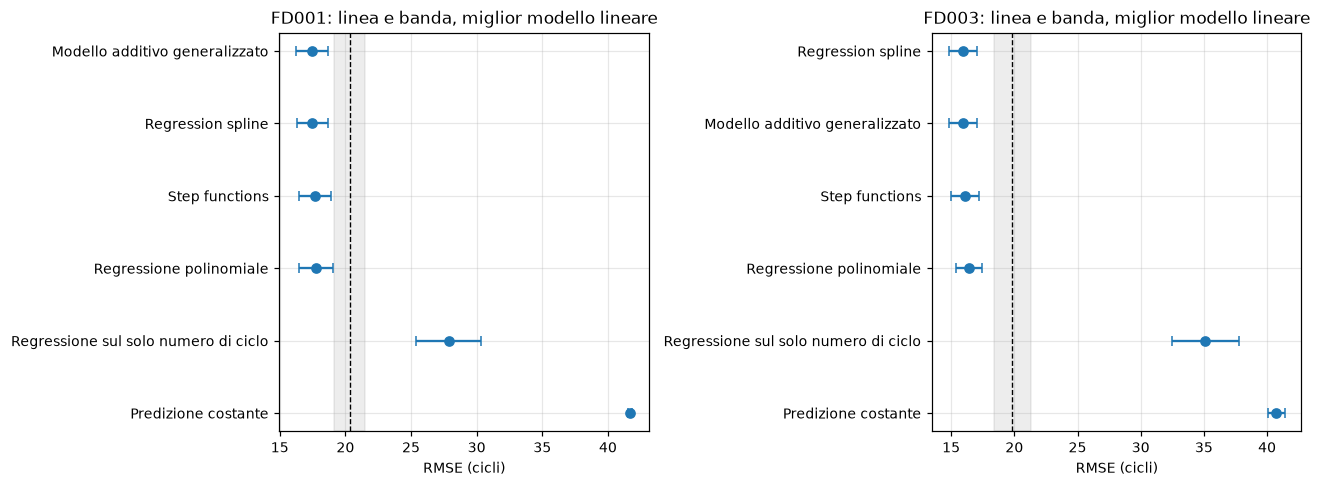

In [3]:
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(12, 4.5))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    table = comparison[subset].sort_values("rmse_mean", ascending=False)
    ax.errorbar(table["rmse_mean"], range(len(table)), xerr=table["rmse_std"], fmt="o", capsize=3)
    reference = best_linear(subset)
    ax.axvline(reference["rmse_mean"], color="black", linewidth=0.9, linestyle="--")
    ax.axvspan(reference["rmse_mean"] - reference["rmse_std"],
               reference["rmse_mean"] + reference["rmse_std"], color="black", alpha=0.07)
    ax.set_yticks(range(len(table)))
    ax.set_yticklabels(table["label"])
    ax.set_xlabel("RMSE (cicli)")
    ax.set_title(f"{subset}: linea e banda, miglior modello lineare")
save(fig, "confronto_blocco_non_lineare")
plt.show()

In [4]:
rows = []
for subset in SUBSETS:
    reference = best_linear(subset)
    for model in MODELS:
        row = comparison[subset].query("model == @model").iloc[0]
        scale = np.sqrt((row["rmse_std"] ** 2 + reference["rmse_std"] ** 2) / 2.0)
        rows.append({
            "sottoinsieme": subset,
            "modello": row["label"],
            "rmse": row["rmse_mean"],
            "dispersione": row["rmse_std"],
            "riferimento_lineare": reference["label"],
            "rmse_riferimento": reference["rmse_mean"],
            "guadagno_cicli": reference["rmse_mean"] - row["rmse_mean"],
            "guadagno_in_dispersioni": (reference["rmse_mean"] - row["rmse_mean"]) / scale,
        })
guadagno = pd.DataFrame(rows)
guadagno.to_csv(TABLES_DIR / "guadagno_su_blocco_lineare.csv", index=False)
guadagno

,sottoinsieme,modello,rmse,dispersione,riferimento_lineare,rmse_riferimento,guadagno_cicli,guadagno_in_dispersioni
0,FD001,Regressione polinomiale,17.751808,1.281043,Regressione lineare multipla,20.345219,2.593411,2.103059
1,FD001,Step functions,17.691893,1.204320,Regressione lineare multipla,20.345219,2.653327,2.222444
2,FD001,Regression spline,17.467998,1.185814,Regressione lineare multipla,20.345219,2.877222,2.428896
3,FD001,Modello additivo generalizzato,17.462329,1.206192,Regressione lineare multipla,20.345219,2.882890,2.412819
4,FD003,Regressione polinomiale,16.439297,1.019997,Forward stepwise selection,19.848596,3.409299,2.721316
5,FD003,Step functions,16.095433,1.080293,Forward stepwise selection,19.848596,3.753162,2.937129
6,FD003,Regression spline,15.914276,1.097465,Forward stepwise selection,19.848596,3.934319,3.061420
7,FD003,Modello additivo generalizzato,15.945531,1.091755,Forward stepwise selection,19.848596,3.903064,3.042863


La figura riporta la media sui 15 fold con la dispersione fra fold; la linea tratteggiata e la
banda grigia sono il miglior modello del blocco lineare con la sua dispersione, cioe' il livello
che questo blocco doveva superare perche' l'ipotesi con cui il blocco precedente si era chiuso
risultasse confermata.

Tre letture, in ordine di robustezza.

Il guadagno sul blocco lineare e' l'unico divario di questa figura che vada considerato reale su
entrambi i sottoinsiemi, ed e' il risultato del blocco. La tabella lo esprime sia in cicli sia in
unita' di dispersione, che e' la scala con cui il progetto decide se due misure siano
distinguibili.

Il divario fra i primi due modelli del blocco e' invece inferiore alla dispersione, e i due non
vengono ordinati. Che a pareggiare siano proprio spline e modello additivo non e' casuale: sono i
due modelli che rappresentano la stessa cosa, una funzione liscia per variabile, e differiscono
per come ne governano la flessibilita', il primo scegliendo quanti nodi usare, il secondo
penalizzando la curvatura di una base fissa.

La regressione polinomiale e' ultima su entrambi i sottoinsiemi. E' l'unico modello del blocco che
rappresenta le interazioni fra variabili, e le paga senza vantaggio: l'espansione additiva, che
tratta ogni variabile separatamente, compra piu' accuratezza a un costo in termini minore.

## 2. Comportamento dei modelli lungo la griglia

Il punteggio del modello selezionato non dice se il minimo sia netto o se la curva sia piatta. La
distinzione conta: su una curva piatta la configurazione scelta e' una fra molte equivalenti, e la
selezione non e' un risultato stabile. Le curve seguenti riportano l'errore in cross-validation di
ogni configurazione esplorata, sulle 5 partizioni usate per la ricerca.

I quattro modelli governano tutti la stessa quantita', la flessibilita' concessa alla relazione,
con parametri diversi: il grado del polinomio, il numero di intervalli, il numero di nodi e il
grado della base, l'intensita' della penalizzazione sulla curvatura. Le quattro curve sono quindi
la stessa lettura fatta quattro volte, e vanno confrontate fra loro.

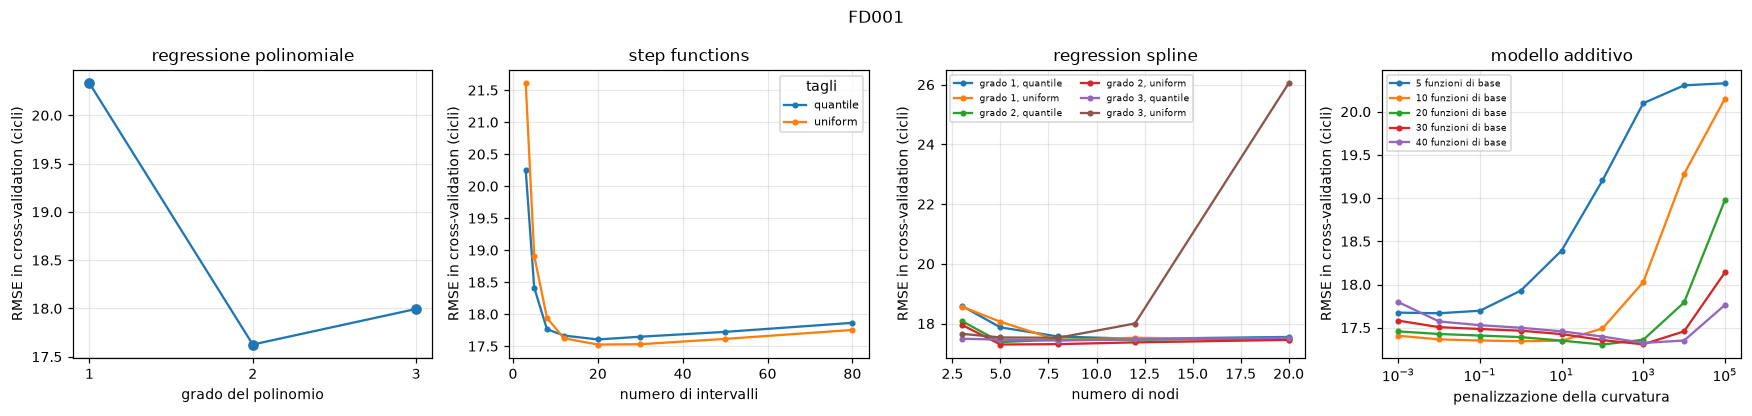

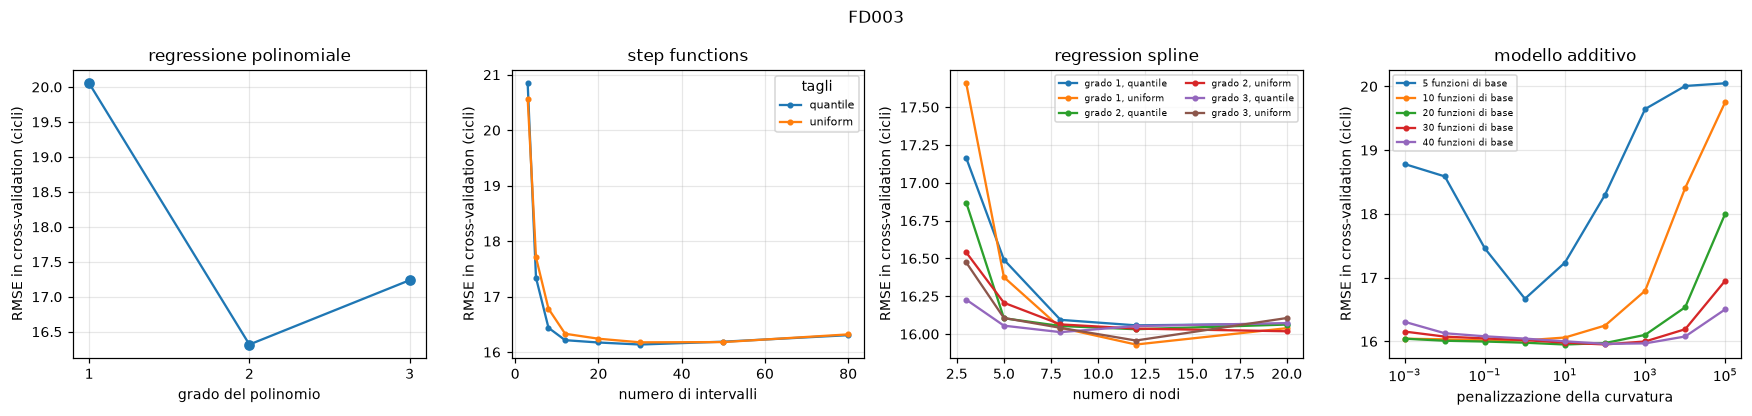

In [5]:
def curve(subset, model, column):
    block = grids[subset].query("model == @model").copy()
    return block.dropna(subset=[column])


for subset in SUBSETS:
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))

    block = curve(subset, "polynomial", "param_model__expand__degree")
    block = block.sort_values("param_model__expand__degree")
    axes[0].plot(block["param_model__expand__degree"], block["mean_test_rmse"], marker="o")
    axes[0].set_xlabel("grado del polinomio")
    axes[0].set_xticks(sorted(block["param_model__expand__degree"].unique()))
    axes[0].set_title("regressione polinomiale")

    block = curve(subset, "step_functions", "param_model__expand__n_bins")
    for strategy, part in block.groupby("param_model__expand__strategy"):
        part = part.sort_values("param_model__expand__n_bins")
        axes[1].plot(part["param_model__expand__n_bins"], part["mean_test_rmse"],
                     marker=".", label=strategy)
    axes[1].set_xlabel("numero di intervalli")
    axes[1].set_title("step functions")
    axes[1].legend(title="tagli", fontsize=7)

    block = curve(subset, "spline", "param_model__expand__n_knots")
    for (degree, knots), part in block.groupby(["param_model__expand__degree",
                                                "param_model__expand__knots"]):
        part = part.sort_values("param_model__expand__n_knots")
        axes[2].plot(part["param_model__expand__n_knots"], part["mean_test_rmse"],
                     marker=".", label=f"grado {int(degree)}, {knots}")
    axes[2].set_xlabel("numero di nodi")
    axes[2].set_title("regression spline")
    axes[2].legend(fontsize=6, ncol=2)

    block = curve(subset, "gam", "param_model__lam")
    for n_splines, part in block.groupby("param_model__n_splines"):
        part = part.sort_values("param_model__lam")
        axes[3].plot(part["param_model__lam"], part["mean_test_rmse"],
                     marker=".", label=f"{int(n_splines)} funzioni di base")
    axes[3].set_xscale("log")
    axes[3].set_xlabel("penalizzazione della curvatura")
    axes[3].set_title("modello additivo")
    axes[3].legend(fontsize=6)

    for ax in axes:
        ax.set_ylabel("RMSE in cross-validation (cicli)")
    fig.suptitle(subset)
    save(fig, f"{subset}_curve_griglie_non_lineari")
    plt.show()

In [6]:
rows = []
for subset in SUBSETS:
    for model in MODELS:
        block = grids[subset].query("model == @model")
        best = block["mean_test_rmse"].min()
        rows.append({
            "sottoinsieme": subset,
            "modello": comparison[subset].query("model == @model")["label"].iloc[0],
            "configurazioni": len(block),
            "rmse_minimo": best,
            "rmse_massimo": block["mean_test_rmse"].max(),
            "escursione_griglia": block["mean_test_rmse"].max() - best,
            "configurazioni_entro_un_ciclo": int((block["mean_test_rmse"] <= best + 1.0).sum()),
        })
piattezza = pd.DataFrame(rows)
piattezza.to_csv(TABLES_DIR / "piattezza_griglie_non_lineari.csv", index=False)
piattezza

,sottoinsieme,modello,configurazioni,rmse_minimo,rmse_massimo,escursione_griglia,configurazioni_entro_un_ciclo
0,FD001,Regressione polinomiale,3,17.626819,20.332182,2.705363,2
1,FD001,Step functions,16,17.526924,21.608219,4.081295,13
2,FD001,Regression spline,30,17.301299,26.046563,8.745264,27
3,FD001,Modello additivo generalizzato,45,17.305216,20.329501,3.024286,37
4,FD003,Regressione polinomiale,3,16.317853,20.053743,3.735891,2
5,FD003,Step functions,16,16.137421,20.846399,4.708977,12
6,FD003,Regression spline,30,15.931232,17.658066,1.726833,28
7,FD003,Modello additivo generalizzato,45,15.951217,20.048966,4.097749,33


Le curve hanno tutte la stessa forma: una discesa rapida quando la flessibilita' passa da nulla a
poca, e poi un tratto lungo e piatto. La tabella lo quantifica con il numero di configurazioni che
cadono entro un ciclo dal minimo della propria griglia.

La conseguenza e' che la configurazione selezionata non va commentata come se fosse un valore
ottimale individuato con precisione. Sul tratto piatto la scelta e' determinata da fluttuazioni
piccole rispetto alla dispersione fra fold, e su partizioni diverse cadrebbe altrove. Cio' che le
curve dicono con sicurezza e' un'altra cosa: che serve poca flessibilita' per ottenere quasi tutto
il guadagno, e che aumentarla oltre quel punto non peggiora ma nemmeno migliora.

Sulle step functions la collocazione dei tagli e' visibile come differenza fra le due curve: i
tagli sui quantili collocano gli intervalli dove le osservazioni sono, quelli di ampiezza uguale
li distribuiscono sull'escursione della variabile. Il punto in cui le due curve si separano dice a
partire da quanti intervalli la differenza inizi a contare.

Sul modello additivo le curve al variare del numero di funzioni di base tendono a sovrapporsi
tranne che a penalizzazione bassa, dove una base piu' ricca ha piu' curvatura da spendere. E' il
comportamento atteso di una penalizzazione che funziona: sopra una certa intensita' il numero di
funzioni di base smette di essere il parametro che governa la flessibilita' effettiva.

## 3. Quanti termini costa il guadagno

I quattro modelli arrivano a risultati vicini con numeri di parametri molto diversi. La figura
mette in relazione il numero di termini della configurazione selezionata con l'errore, e serve a
leggere il costo in complessita' di ciascuna strada.

Il confronto va fatto con una cautela. Per i tre modelli a espansione il numero di termini e' il
numero di colonne stimate per minimi quadrati, e ogni colonna e' un parametro libero. Per il
modello additivo i termini sono le variabili, ma il numero di parametri effettivi e' un'altra
quantita', riportata nella sezione dedicata come gradi di liberta' effettivi.

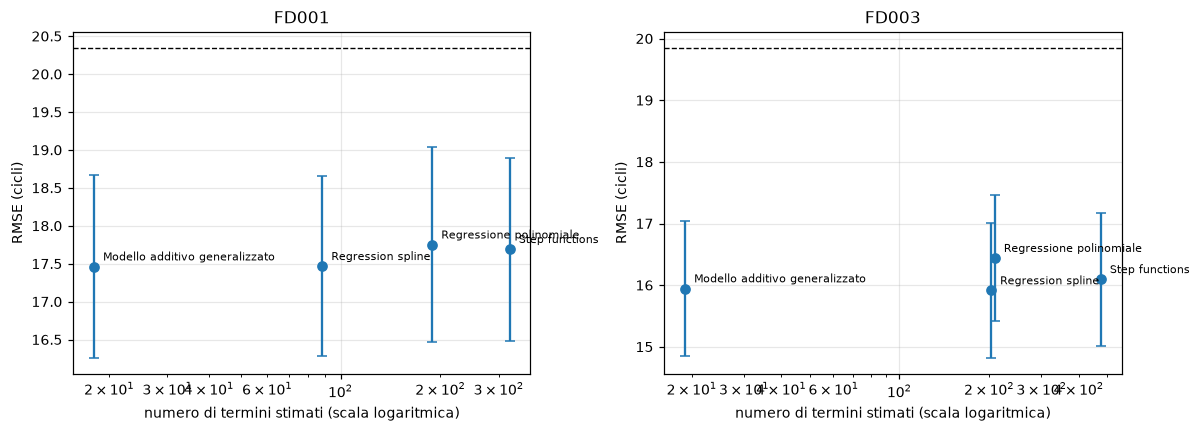

In [7]:
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(11, 4))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    block = comparison[subset][comparison[subset]["model"].isin(MODELS)]
    ax.errorbar(block["n_nonzero"], block["rmse_mean"], yerr=block["rmse_std"],
                fmt="o", capsize=3)
    for _, row in block.iterrows():
        ax.annotate(row["label"], (row["n_nonzero"], row["rmse_mean"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=7)
    reference = best_linear(subset)
    ax.axhline(reference["rmse_mean"], color="black", linewidth=0.9, linestyle="--")
    ax.set_xscale("log")
    ax.set_xlabel("numero di termini stimati (scala logaritmica)")
    ax.set_ylabel("RMSE (cicli)")
    ax.set_title(subset)
save(fig, "complessita_errore_non_lineare")
plt.show()

Non c'e' relazione fra numero di termini ed errore. Il modello con meno termini e quello con piu'
termini stanno vicini fra loro, e il modello con il maggior numero di parametri non e' il migliore
su nessuno dei due sottoinsiemi.

La lettura e' coerente con quella della sezione precedente. Se la curva di validazione e' piatta
oltre una flessibilita' minima, allora aggiungere termini non compra accuratezza, e i modelli che
ne aggiungono molti stanno spendendo parametri per rappresentare struttura che non e' predittiva.
Che non li faccia peggiorare in modo visibile dipende dal fatto che le righe sono decine di
migliaia: con una numerosita' minore lo stesso numero di termini produrrebbe sovradattamento
leggibile.

## 4. Le funzioni stimate dal modello additivo

Il modello additivo e' l'unico del blocco che si commenta guardando le funzioni invece dei
coefficienti: per ogni variabile stima una funzione della sola variabile, e la somma delle
funzioni e' la predizione. Le curve seguenti mostrano quelle funzioni sul dominio osservato di
ciascuna variabile, con la banda di confidenza calcolata dalla libreria.

L'ordinata e' in cicli e le curve sono centrate, quindi l'escursione verticale di ciascuna e'
direttamente interpretabile: e' di quanti cicli quella variabile, da sola, sposta la predizione
passando dal valore piu' basso al piu' alto che assume. L'ascissa e' nelle unita' originali della
variabile.

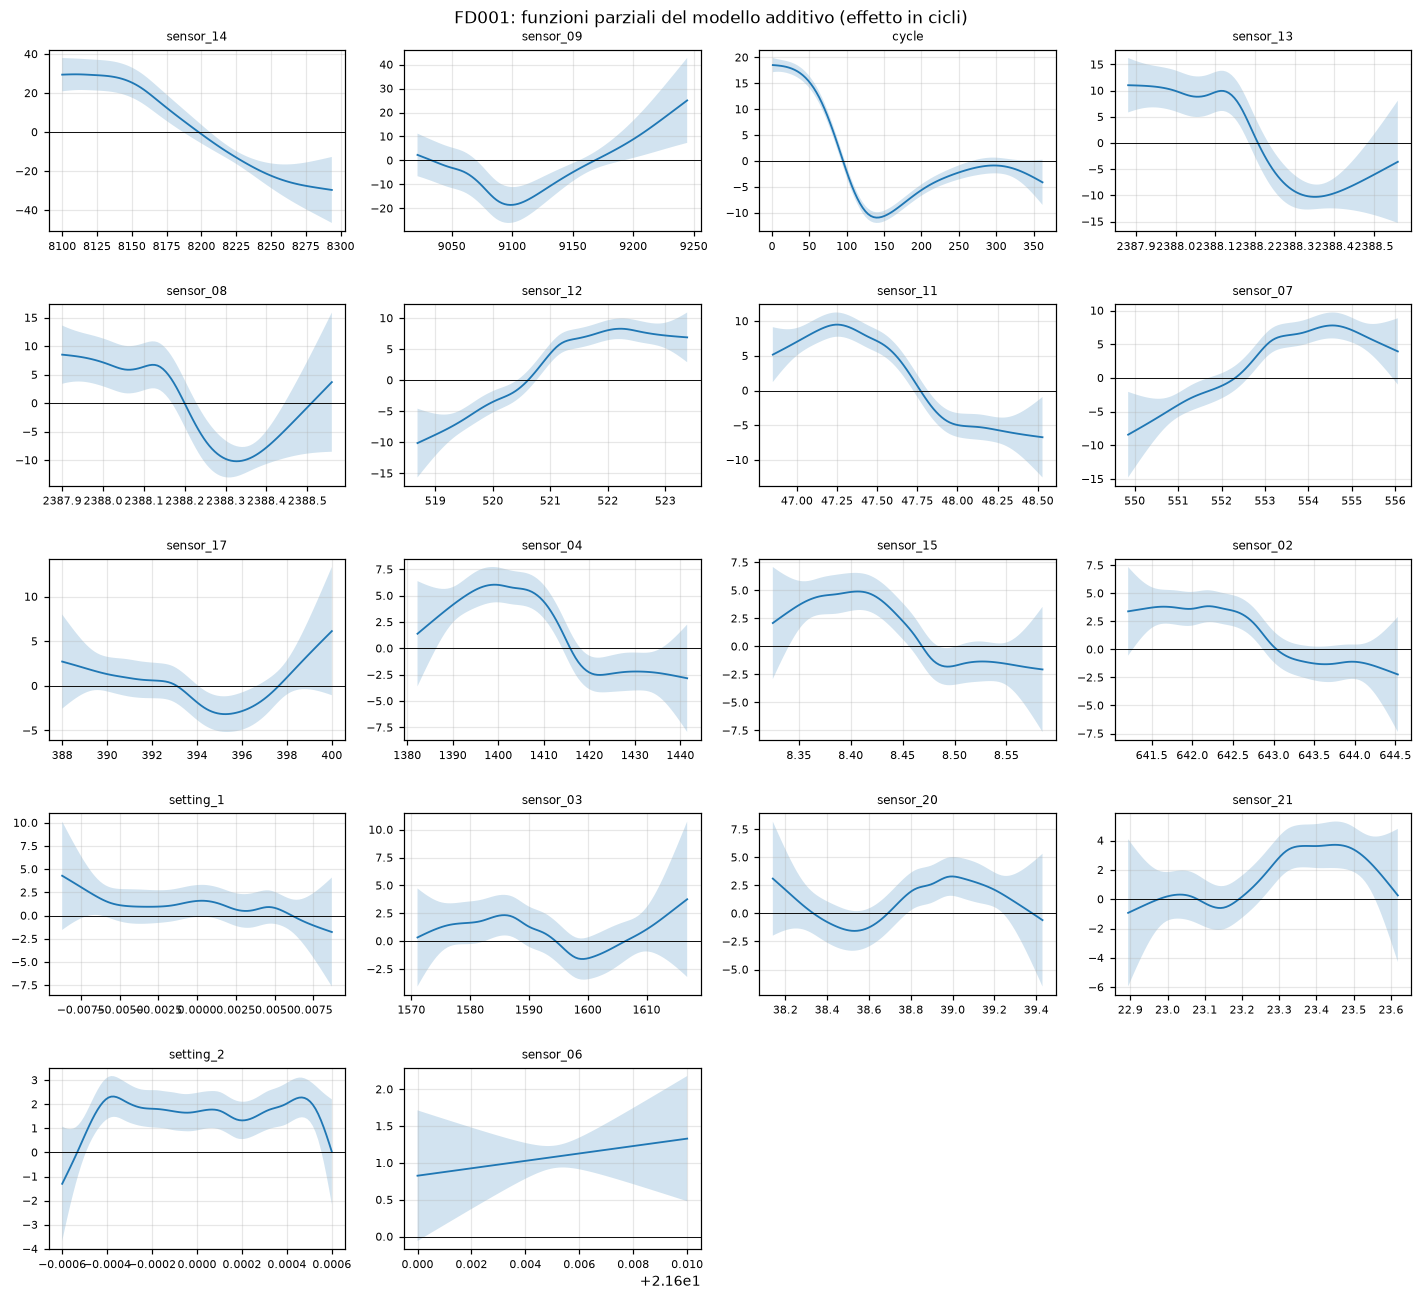

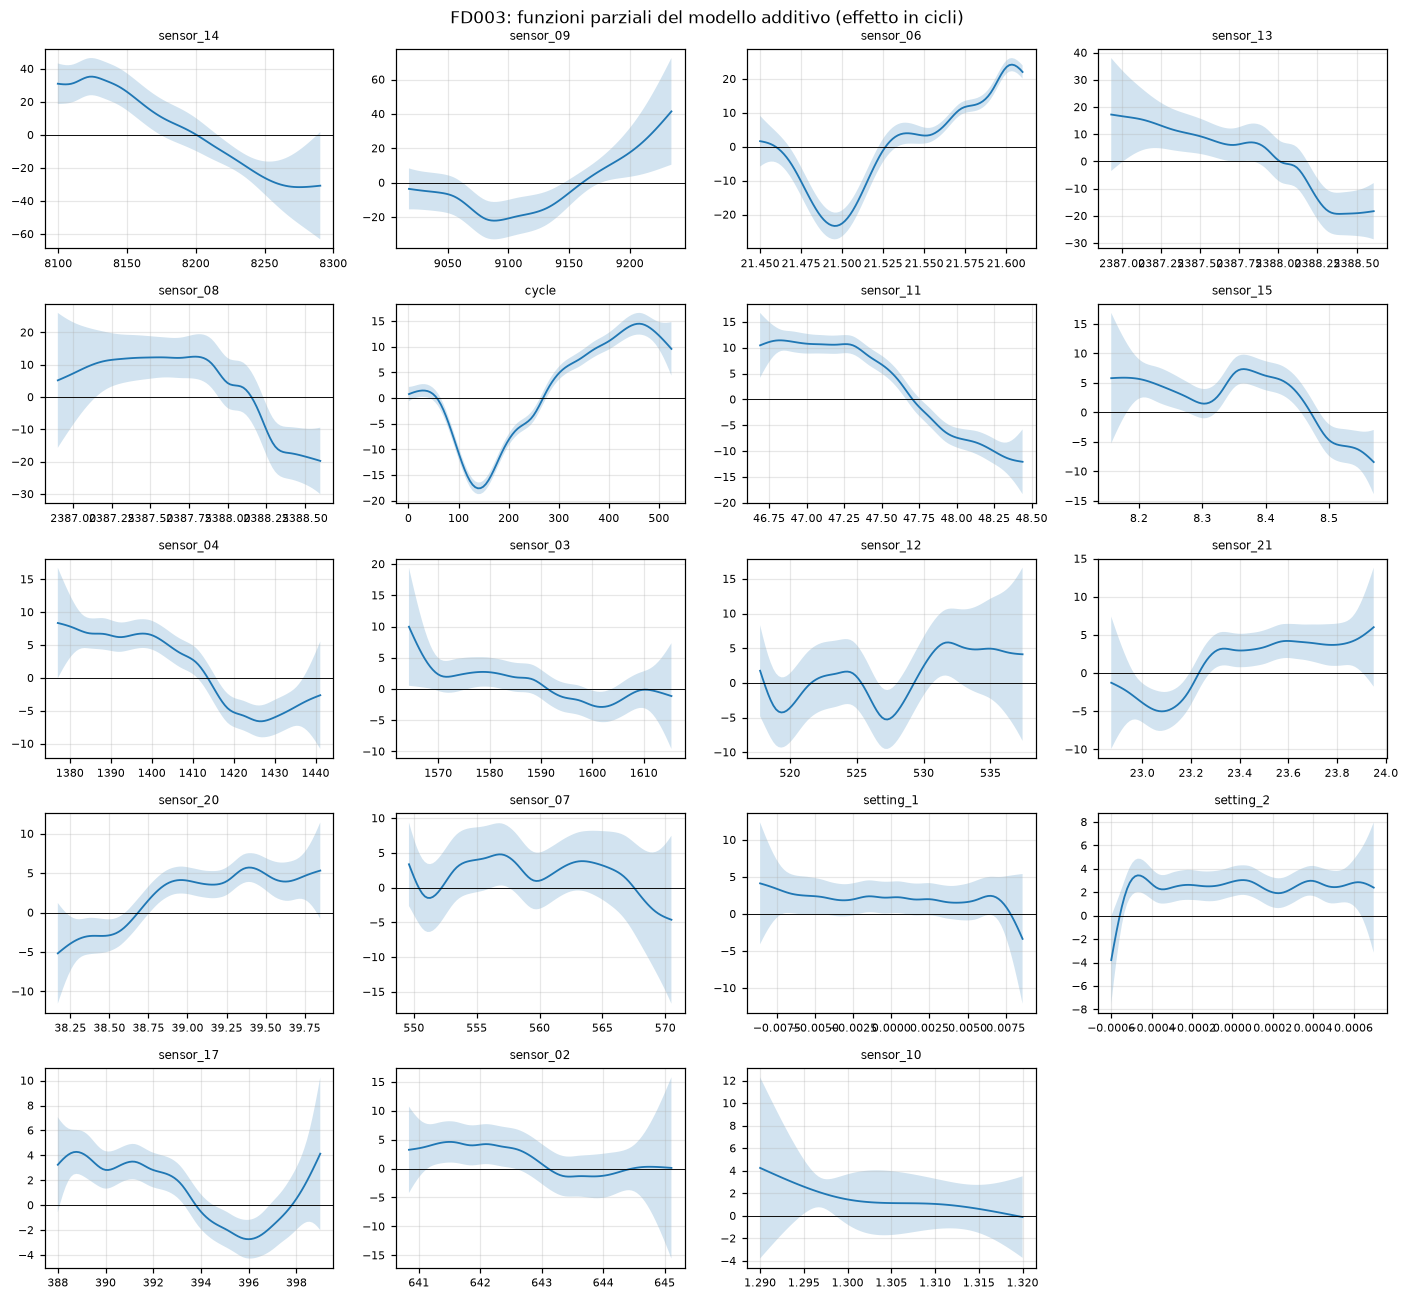

In [8]:
for subset in SUBSETS:
    block = terms[subset].query("model == 'gam'").sort_values("effect_range", ascending=False)
    order = block["feature"].tolist()
    n_cols = 4
    n_rows = int(np.ceil(len(order) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 2.4 * n_rows))
    axes = np.atleast_2d(axes)
    for ax, feature in zip(axes.ravel(), order):
        shape = partial[subset].query("feature == @feature")
        ax.plot(shape["x_original"], shape["effect"], linewidth=1.2)
        ax.fill_between(shape["x_original"], shape["ci_low"], shape["ci_high"], alpha=0.2)
        ax.axhline(0.0, color="black", linewidth=0.6)
        ax.set_title(feature, fontsize=8)
        ax.tick_params(labelsize=7)
    for ax in axes.ravel()[len(order):]:
        ax.axis("off")
    fig.suptitle(f"{subset}: funzioni parziali del modello additivo (effetto in cicli)")
    save(fig, f"{subset}_funzioni_parziali_gam")
    plt.show()

In [9]:
rows = []
for subset in SUBSETS:
    block = terms[subset].query("model == 'gam'")[["feature", "edof", "effect_range", "p_value"]]
    block = block.sort_values("effect_range", ascending=False).copy()
    block.insert(0, "sottoinsieme", subset)
    rows.append(block)
gam_termini = pd.concat(rows, ignore_index=True)
gam_termini.to_csv(TABLES_DIR / "gam_termini.csv", index=False)

for subset in SUBSETS:
    block = gam_termini.query("sottoinsieme == @subset")
    lineari = block[block["edof"] < 1.5]["feature"].tolist()
    print(f"{subset}: gradi di liberta' effettivi totali {block['edof'].sum():.1f} "
          f"su {len(block)} termini")
    print(f"{subset}: termini ridotti a una retta dalla penalizzazione: "
          f"{' '.join(lineari) if lineari else 'nessuno'}")
gam_termini.head(12)

FD001: gradi di liberta' effettivi totali 123.7 su 18 termini
FD001: termini ridotti a una retta dalla penalizzazione: sensor_06
FD003: gradi di liberta' effettivi totali 197.5 su 19 termini
FD003: termini ridotti a una retta dalla penalizzazione: nessuno


,sottoinsieme,feature,edof,effect_range,p_value
0,FD001,sensor_14,4.130169,59.251227,1.110223e-16
1,FD001,sensor_09,6.547692,43.597277,1.110223e-16
2,FD001,cycle,9.581510,29.434770,1.110223e-16
3,FD001,sensor_13,5.595041,21.321674,1.110223e-16
4,FD001,sensor_08,6.760941,18.701378,1.110223e-16
5,FD001,sensor_12,7.626569,18.415148,1.110223e-16
6,FD001,sensor_11,7.667953,16.225329,1.110223e-16
7,FD001,sensor_07,7.289009,16.223963,1.110223e-16
8,FD001,sensor_17,6.545677,9.307602,7.701173e-12
9,FD001,sensor_04,7.564066,8.876625,1.110223e-16


Due quantita' descrivono ciascun termine e non vanno confuse. I gradi di liberta' effettivi
misurano quanta flessibilita' la penalizzazione ha lasciato alla funzione: un valore vicino a uno
indica una funzione ormai indistinguibile da una retta, e quindi una variabile che entra nel
modello additivo come sarebbe entrata in un modello lineare. L'escursione misura invece l'ampiezza
dell'effetto in cicli. Sono indipendenti: una variabile puo' avere una funzione molto curva e un
effetto piccolo, oppure un effetto grande e perfettamente lineare.

E' questa distinzione a spiegare il guadagno del blocco. Se tutte le funzioni fossero rette il
modello additivo coinciderebbe con la regressione lineare multipla e il guadagno sarebbe nullo:
sono i termini con gradi di liberta' effettivi nettamente sopra uno a fare la differenza, e la
tabella dice quali variabili siano.

Il numero di ciclo merita attenzione a se'. Il target e' censurato a 125 cicli, quindi nella prima
fase della vita di ogni motore la vita residua e' costante per costruzione, e la relazione fra
ciclo e target non e' una retta ma una curva che si appiattisce. Un modello lineare non puo'
rappresentare quella forma, una funzione liscia si'. Va tenuto presente che sulle traiettorie di
addestramento, complete fino al guasto, il legame fra numero di ciclo e vita residua e' piu' forte
che sulle traiettorie di verifica, troncate in un punto casuale.

I livelli di significativita' della tabella sono riportati per completezza e non vanno usati come
test: sono calcolati su decine di migliaia di righe che non sono osservazioni indipendenti, quindi
sono sistematicamente ottimistici.

## 5. Quali variabili pesano, e se i modelli concordano

I tre modelli a espansione non hanno un coefficiente per variabile ma molti termini per variabile.
Per confrontarli fra loro e con il modello additivo si aggrega: per ciascuna variabile si somma
l'ampiezza dei coefficienti dei termini che ne derivano, e si esprime il risultato come quota del
totale. Per il modello additivo la quantita' corrispondente e' l'escursione della funzione
parziale.

L'aggregazione e' una lettura, non una misura di importanza in senso stretto. Le basi non sono
normalizzate allo stesso modo fra modelli, quindi le quote non sono confrontabili in valore
assoluto: cio' che si confronta e' l'ordinamento delle variabili che ciascun modello produce. I
termini del polinomio che combinano due variabili sono attribuiti a una voce separata, perche'
assegnarli a una delle due sarebbe arbitrario, e la loro quota complessiva e' essa stessa un
risultato da leggere.

In [10]:
def variable_share(subset, model):
    block = terms[subset].query("model == @model")
    weight = "effect_range" if model == "gam" else "abs_coef"
    share = block.groupby("feature")[weight].sum()
    return share / share.sum()


rows = []
for subset in SUBSETS:
    share = pd.DataFrame({model: variable_share(subset, model) for model in MODELS})
    share = share.fillna(0.0).sort_values("gam", ascending=False)
    share.index.name = "feature"
    share = share.reset_index()
    share.insert(0, "sottoinsieme", subset)
    rows.append(share)
quote = pd.concat(rows, ignore_index=True)
quote.to_csv(TABLES_DIR / "peso_variabili_non_lineari.csv", index=False)

for subset in SUBSETS:
    block = quote.query("sottoinsieme == @subset and feature == 'interazione'")
    if len(block):
        print(f"{subset}: quota del polinomio nei termini di interazione "
              f"{block['polynomial'].iloc[0]:.1%}")
quote.head(12)

FD001: quota del polinomio nei termini di interazione 53.0%
FD003: quota del polinomio nei termini di interazione 68.4%


,sottoinsieme,feature,polynomial,step_functions,spline,gam
0,FD001,sensor_14,0.050311,0.199394,0.096724,0.212045
1,FD001,sensor_09,0.054902,0.062881,0.120823,0.156023
2,FD001,cycle,0.149747,0.095629,0.046886,0.105339
3,FD001,sensor_13,0.022020,0.109066,0.315950,0.076305
4,FD001,sensor_08,0.022841,0.084983,0.073352,0.066927
5,FD001,sensor_12,0.026396,0.072518,0.038111,0.065903
6,FD001,sensor_11,0.032113,0.079410,0.032926,0.058066
7,FD001,sensor_07,0.021706,0.056490,0.024267,0.058061
8,FD001,sensor_17,0.009792,0.015816,0.070650,0.033310
9,FD001,sensor_04,0.017509,0.056620,0.016805,0.031767


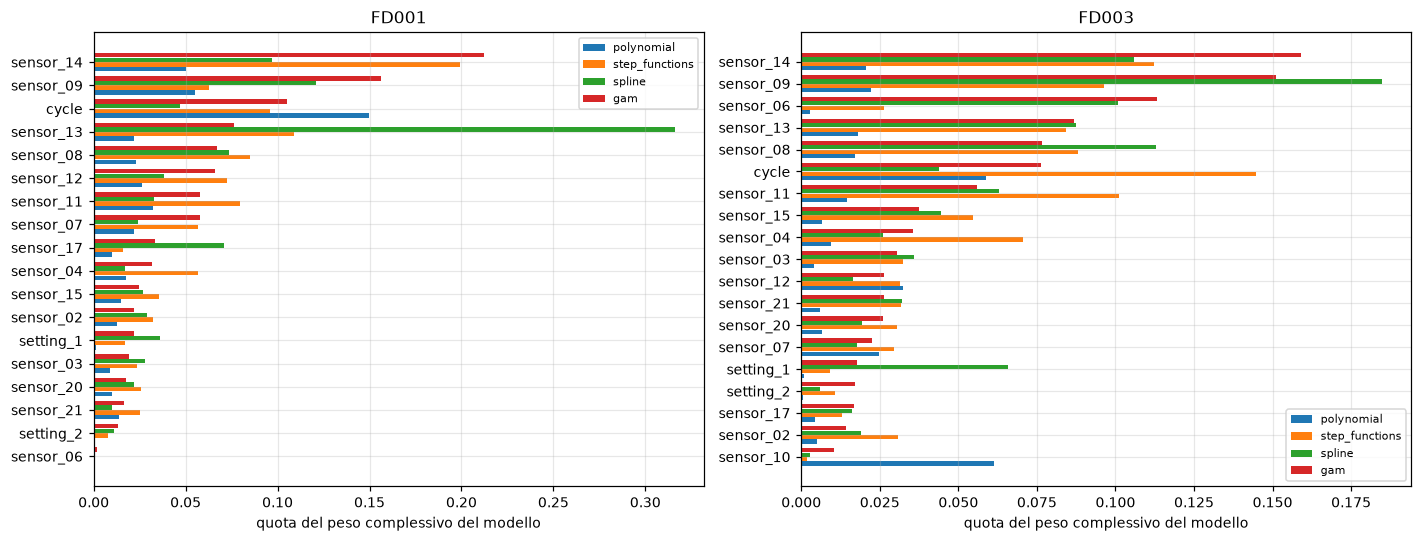

In [11]:
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(13, 5))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    block = quote.query("sottoinsieme == @subset and feature != 'interazione'")
    block = block.sort_values("gam")
    y = np.arange(len(block))
    for offset, model in zip((-0.3, -0.1, 0.1, 0.3), MODELS):
        ax.barh(y + offset, block[model], height=0.19, label=model)
    ax.set_yticks(y)
    ax.set_yticklabels(block["feature"])
    ax.set_xlabel("quota del peso complessivo del modello")
    ax.set_title(subset)
    ax.legend(fontsize=7)
save(fig, "peso_variabili_non_lineari")
plt.show()

In [12]:
rows = []
for subset in SUBSETS:
    block = quote.query("sottoinsieme == @subset and feature != 'interazione'")
    ranks = block[list(MODELS)].rank(ascending=False)
    corr = ranks.corr(method="spearman")
    for i, a in enumerate(MODELS):
        for b in MODELS[i + 1:]:
            rows.append({"sottoinsieme": subset, "modello_a": a, "modello_b": b,
                         "concordanza_ordinamenti": corr.loc[a, b]})
concordanza = pd.DataFrame(rows)
concordanza.to_csv(TABLES_DIR / "concordanza_ordinamenti_variabili.csv", index=False)
concordanza

,sottoinsieme,modello_a,modello_b,concordanza_ordinamenti
0,FD001,polynomial,step_functions,0.919505
1,FD001,polynomial,spline,0.626419
2,FD001,polynomial,gam,0.902993
3,FD001,step_functions,spline,0.663571
4,FD001,step_functions,gam,0.884417
5,FD001,spline,gam,0.859649
6,FD003,polynomial,step_functions,0.428070
7,FD003,polynomial,spline,0.022807
8,FD003,polynomial,gam,0.252632
9,FD003,step_functions,spline,0.628070


La tabella di concordanza riporta la correlazione fra gli ordinamenti di variabili prodotti da
ciascuna coppia di modelli. Valori alti dicono che i modelli, pur costruendo termini diversi,
attribuiscono il peso alle stesse variabili; valori bassi dicono che l'ordinamento dipende dalla
trasformazione e non dal dato, e in quel caso nessuno dei due ordinamenti va presentato come
l'importanza delle variabili.

La quota del polinomio che risiede nei termini di interazione va letta insieme alla posizione del
polinomio in graduatoria. Una quota consistente spesa in interazioni, a fronte del risultato
peggiore del blocco, significa che quella parte di modello non e' informativa: le interazioni
raccolgono peso in stima senza tradursi in accuratezza sulle unita' non viste.

## 6. Diagnostica dell'esperimento

La tabella raccoglie cio' che e' successo durante la ricerca su griglia e che non compare nei
punteggi: quante configurazioni sono state valutate, se la configurazione selezionata cada su un
estremo della griglia, quante configurazioni non siano state valutabili, quante mancate
convergenze si siano verificate, quante colonne l'espansione abbia effettivamente generato.

E' la parte che rende verificabile il resto. Un estremo selezionato significa che la griglia
taglia fuori configurazioni potenzialmente migliori e impone di estenderla e rieseguire la
ricerca. Una configurazione non valutabile sparirebbe altrimenti in silenzio, perche' la ricerca
su griglia le assegna un punteggio non definito e prosegue riportando un vincitore regolare.

In [13]:
rows = []
for subset in SUBSETS:
    block = diagnostics[subset].copy()
    block.insert(0, "sottoinsieme", subset)
    rows.append(block)
diagnostica = pd.concat(rows, ignore_index=True)
colonne = ["sottoinsieme", "model", "n_configurations", "boundary", "failed_configurations",
           "convergence_warnings", "expansion_columns", "expansion_columns_nominal",
           "search_seconds"]
diagnostica = diagnostica[[c for c in colonne if c in diagnostica.columns]]
diagnostica.to_csv(TABLES_DIR / "diagnostica_blocco_non_lineare.csv", index=False)

print("configurazioni non valutabili in tutto il blocco:",
      int(diagnostica["failed_configurations"].fillna(0).sum()))
print("mancate convergenze in tutto il blocco:",
      int(diagnostica["convergence_warnings"].fillna(0).sum()))
print("configurazioni selezionate su un estremo della griglia:",
      diagnostica["boundary"].dropna().tolist() or "nessuna")
diagnostica

configurazioni non valutabili in tutto il blocco: 0
mancate convergenze in tutto il blocco: 0
configurazioni selezionate su un estremo della griglia: ['model__expand__degree=minimo']


,sottoinsieme,model,n_configurations,boundary,failed_configurations,convergence_warnings,expansion_columns,expansion_columns_nominal,search_seconds
0,FD001,polynomial,3,NaN,0,0,NaN,NaN,3.930724
1,FD001,step_functions,16,NaN,0,0,360.0,360.0,9.781234
2,FD001,spline,30,NaN,0,0,NaN,NaN,5.250064
3,FD001,gam,45,NaN,0,0,NaN,NaN,73.123726
4,FD003,polynomial,3,NaN,0,0,NaN,NaN,5.173369
5,FD003,step_functions,16,NaN,0,0,475.0,570.0,12.286314
6,FD003,spline,30,model__expand__degree=minimo,0,0,NaN,NaN,6.736146
7,FD003,gam,45,NaN,0,0,NaN,NaN,134.569235


Un solo estremo resta selezionato, il grado minimo della base spline su FD003, e resta per una
decisione presa e non per una griglia non estesa. Il grado immediatamente inferiore produce
funzioni indicatrici su intervalli di ampiezza uguale, che sono le step functions gia' presenti in
tabella come modello a se': l'estensione porterebbe a un modello noto invece che a uno spazio
nuovo, come accade a Elastic Net verso il lato di Ridge. In piu' quella configurazione non e'
valutabile, perche' con grado nullo ed estrapolazione costante la trasformazione fallisce su
qualunque valore fuori dall'intervallo osservato in addestramento, condizione che si verifica in
ogni fold. La verifica ha riguardato tutte le combinazioni di grado ed estrapolazione, e il
difetto e' circoscritto a quella.

L'estremo e' quindi un limite dichiarato e non una griglia da estendere. Va letto insieme al
risultato: su FD003 il modello preferisce la base meno flessibile fra quelle disponibili, e le
step functions, che sono il caso limite in quella direzione, sono a una frazione di dispersione
dalla spline. Le due indicazioni concordano.

Le colonne generate dall'espansione, confrontate con quelle nominali, mostrano dove la
discretizzazione ha rimosso intervalli di ampiezza nulla. Accade solo con tagli sui quantili e
solo su variabili che assumono pochi valori distinti, ed e' una proprieta' del dato che questo
blocco rende visibile e che i modelli lineari non mostravano: alcune letture di sensori sono
quantizzate dallo strumento di misura.

## 7. Sintesi del blocco

Il blocco risponde alla domanda con cui si era chiuso il precedente. Il limite dei modelli lineari
stava nella forma della relazione: consentire a ciascuna variabile di entrare con una funzione non
lineare abbassa l'errore di una quantita' che supera la dispersione fra fold su entrambi i
sottoinsiemi, mentre l'intero blocco lineare, dalla regressione multipla ai modelli regolarizzati
alla selezione delle variabili, era rimasto entro una frazione minima di quella stessa
dispersione.

Il guadagno viene dall'additivita' non lineare e non dalle interazioni. I tre modelli additivi
stanno davanti al polinomio con interazioni su entrambi i sottoinsiemi, e il polinomio spende in
termini incrociati una quota del proprio peso senza ricavarne accuratezza.

Serve poca flessibilita'. Le curve di validazione scendono rapidamente e poi restano piatte, il
numero di termini non e' correlato all'errore, e il modello con meno parametri e' fra i primi. La
configurazione selezionata da ciascuna griglia va commentata come un punto su un tratto piatto e
non come un ottimo individuato con precisione.

Spline e modello additivo non sono distinguibili fra loro. La graduatoria del progetto resta
aperta: si chiudera' quando anche i blocchi sugli alberi e sui metodi a margine e sulle reti
saranno conclusi.

Tre limiti vanno dichiarati.

I punteggi sono ottimistici, perche' la cross-validation non e' annidata e la ricerca degli
iperparametri usa le stesse partizioni su cui la prestazione viene poi misurata. La distorsione
cresce con il numero di configurazioni esplorate, e in questo blocco quel numero varia di un
ordine di grandezza fra i modelli: la tabella di diagnostica riporta quante configurazioni ciascun
modello abbia esplorato. Il confronto fra le righe non e' quindi a parita' di questo fattore, e la
penalizzazione implicita ricade sul modello che ne esplora meno.

Il modello additivo e' l'unico del confronto stimato da una libreria diversa da scikit-learn,
attraverso un adattatore scritto per il progetto. L'adattatore non modifica la stima, ma resta un
punto in cui la catena non e' quella usata da tutti gli altri modelli.

Tutte le misure di questo notebook sono in cross-validation. Nessuna riga dell'insieme di verifica
ufficiale e' stata letta, e la stima non condizionata dalle scelte del progetto arrivera' solo a
graduatoria chiusa.